# DATASCI 350 - Data Science Computing

## Assignment 04: Git in depth

This assignment has two parts. Tasks 01 to 08 go deeper into commands you saw in lectures 05 to 07, with all setup steps given. Tasks 09 to 12 cover commands we have not discussed in class: research how they work and explain each one in your own words. Good starting points are `git help <command>` and the free Pro Git book (<https://git-scm.com/book>).

Several tasks use the `reading-list` repository you built in assignment 03. Where a task needs a fresh sandbox repository, the setup commands are given in full: run them exactly as written, then solve the task.

For each task, record the command(s) you used and a one- or two-sentence explanation in your own words. Screenshots are welcome but not required if you paste the commands and their output.

### Instructions

You must complete this assignment individually. You may use notes, books, and AI tools, but you must submit original work. Any errors introduced by AI tools are your responsibility, so always double-check your answers. Acknowledge all resources used, including input from classmates and AI, in a short note at the end of your submission. If you are unsure about permissible resources or proper acknowledgement, please ask the instructor.

### Submission

Submit your solutions as a single Jupyter notebook or a PDF file to Canvas.

### Task 01: stash basics

In your `reading-list` repository, add one line to `README.md` but do not commit it. Run `git stash`, then show with `git status` that the working tree is clean. Bring the change back with `git stash pop`, then discard it (check `git restore` or simply edit the file back). In one sentence: where was your change while it was stashed?

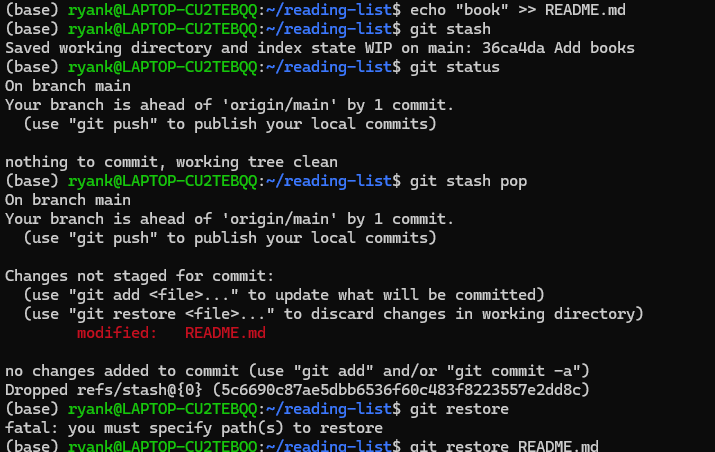

echo "book" >> README.md

git stash

git status

git stash pop

git restore README.md




it was temporarily in git stash

### Task 02: amend a forgotten file

In `reading-list`, create a file `notes.md` with one line and commit it with the message "Add notes". Then create a second file `todo.md`, which you meant to include in that commit. Add it to the previous commit with `git add` and `git commit --amend --no-edit`. Show with `git log --oneline` that there is still only one "Add notes" commit.

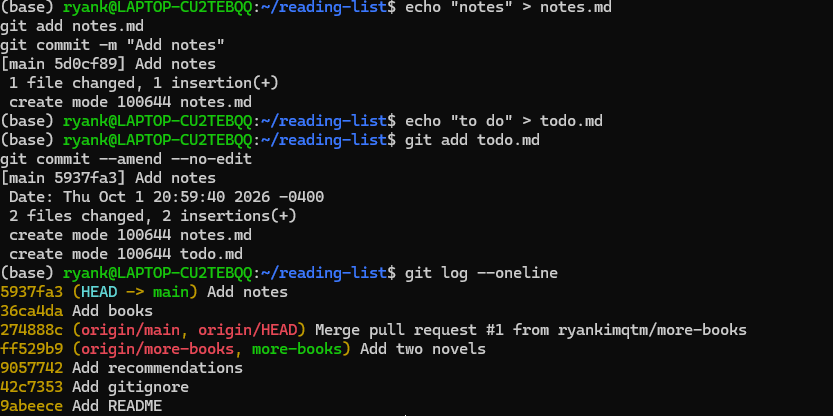

echo "notes" > notes.md

git add notes.md

git commit -m "Add notes"

echo "to do" > todo.md

git add todo.md

git commit --amend --no-edit

git log --oneline

### Task 03: log detective

Run `git log --oneline` in `reading-list`. How many commits does the repository have, and what is the hash of the oldest one? In one sentence: what information does the full `git log` show that `--oneline` leaves out?

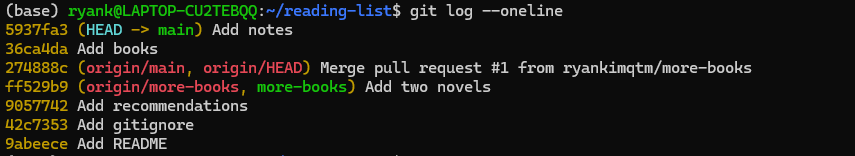

7 commits and oldest is 9abeece

the full git log shows author date and the full commit hash while th e --oneline only shows the short hash and the message leaving out anything else

### Task 04: two diffs

In `reading-list`, modify any file and run `git diff`. Now stage the file and run `git diff` again, then `git diff --staged`. Paste the three outputs. In one sentence: why is the second `git diff` empty?

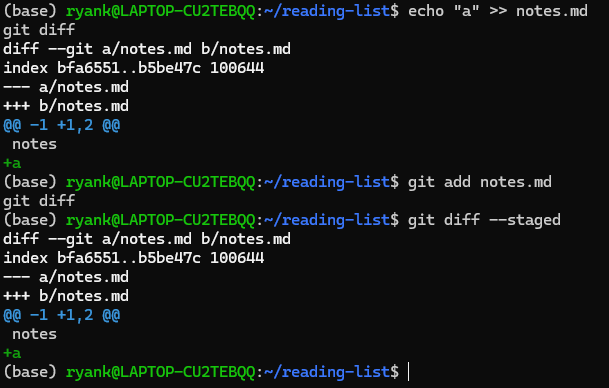

echo "a" >> notes.md

git diff

git add notes.md

git diff

git diff --staged

second git diff is empty bc change was stanged so not an unstaged change

### Task 05: soft vs hard reset

Warning: `git reset --hard` deletes work permanently. Run it only inside the two sandbox repositories you create for this task, never in a repository you care about.

Create two identical sandbox repositories. Run this setup twice, once with `reset-soft` and once with `reset-hard` as the folder name:

```bash
mkdir reset-soft
cd reset-soft
git init
echo "line one" > notes.txt
git add notes.txt
git commit -m "First commit"
echo "line two" >> notes.txt
git commit -am "Second commit"
cd ..
```

In `reset-soft`, run `git reset --soft HEAD~1`. In `reset-hard`, run `git reset --hard HEAD~1`. For each repository, report what `git status` shows and what `notes.txt` contains. Two sentences: what did each reset keep, and what did it throw away?

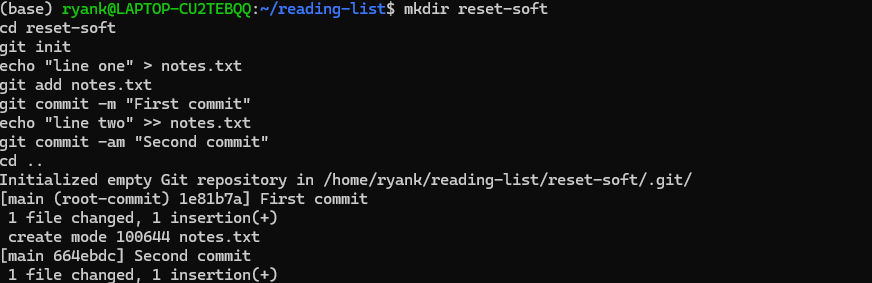
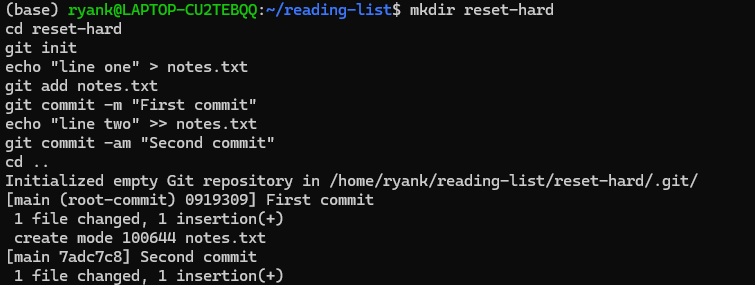
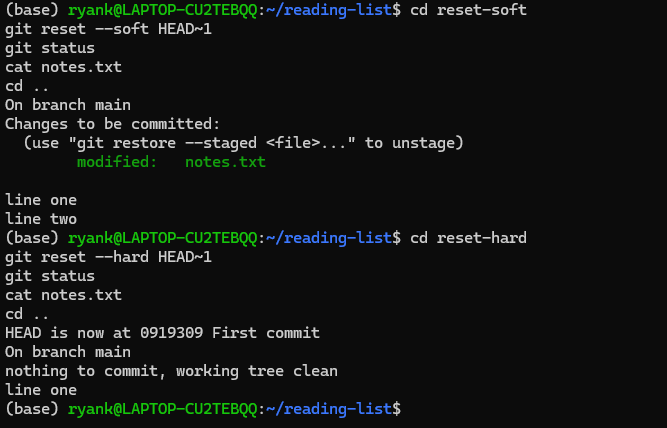

soft reset kept changes from the second commit leaving them staged while the hard reset removed the second commit and threw away its changes

### Task 06: detached HEAD

In `reading-list`, make sure `git status` reports a clean tree. Check out your oldest commit by its hash (from Task 03). Git prints a warning about a "detached HEAD" state: explain in your own words what it means. Then return safely with `git switch main`.

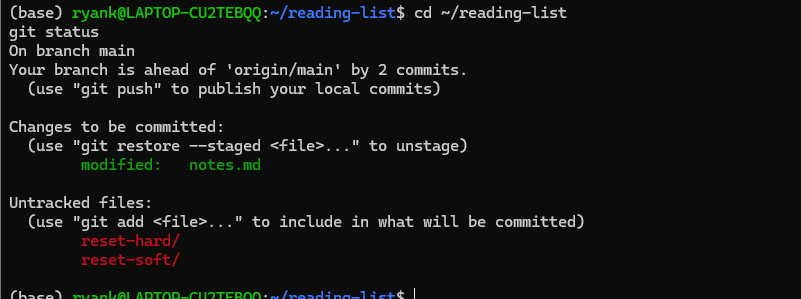
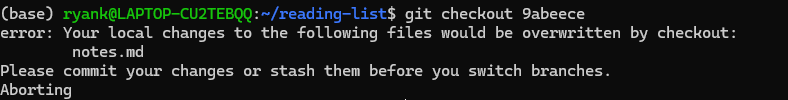
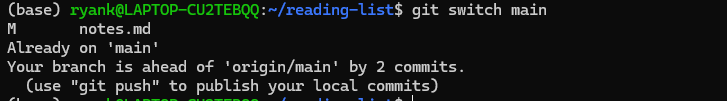

cd ~/reading-list

git status

git checkout 9abeece

git switch main

i think detached HEAD state means I am viewing an older commit directly instead of being on a branch


### Task 07: conflict clinic

Run this setup exactly as written. The final command produces a merge conflict on purpose:

```bash
mkdir conflict-practice
cd conflict-practice
git init
echo "The project starts here." > plan.txt
git add plan.txt
git commit -m "Add plan"
git switch -c feature
echo "The project starts with data cleaning." > plan.txt
git commit -am "Update plan on feature"
git switch main
echo "The project starts with data collection." > plan.txt
git commit -am "Update plan on main"
git merge feature
```

Open `plan.txt`, resolve the conflict by keeping the sentence you prefer, and complete the merge. In two sentences: what do the three marker lines (`<<<<<<<`, `=======`, `>>>>>>>`) delimit?

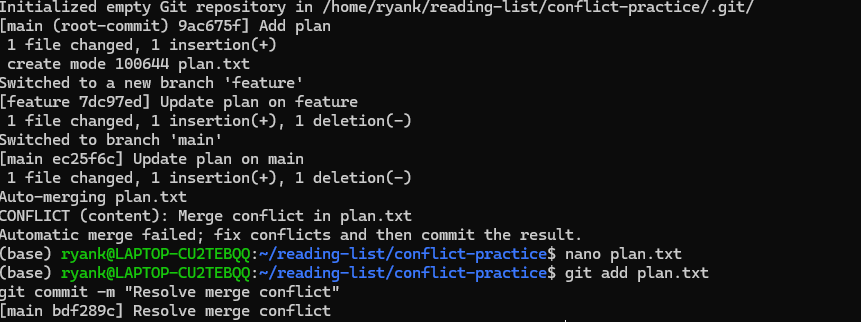

<<<<<<< starts a version ======= seperates two versions and >>>>>>> ends a version

### Task 08: GitHub CLI starter

Using the GitHub CLI from lecture 07: check that you are logged in with `gh auth status`, open your `reading-list` repository in the browser with `gh repo view --web`, and list its issues with `gh issue list`. The issue you opened in assignment 03 appears in the list.

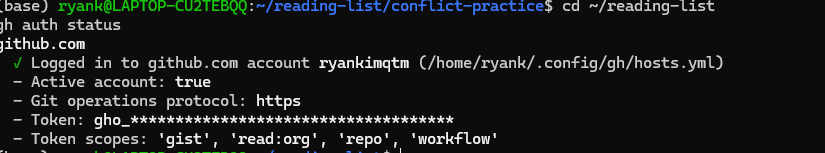

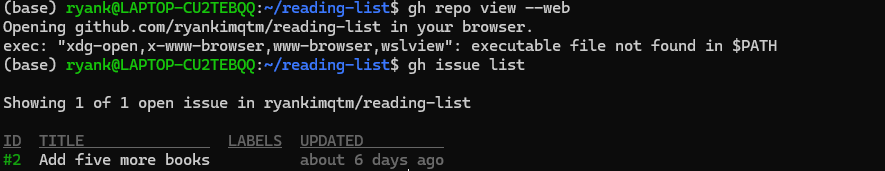

### Task 09: tag a release (research)

Create an annotated tag named `v1.0` on your `reading-list` repository and push it to GitHub. Confirm on GitHub that the tag appears. One sentence: what is the difference between a lightweight and an annotated tag?

cd ~/reading-list

git tag -a v1.0 -m "Version 1.0"

git push origin v1.0

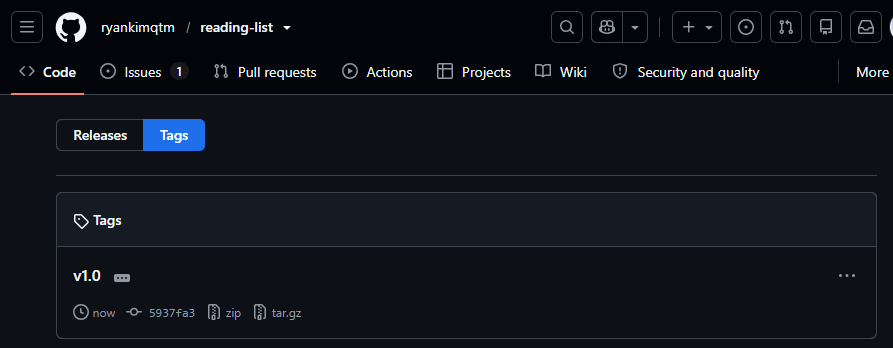

A lightweight tag is just a name pointing to a commit, while an annotated tag also stores information like a message or an author

### Task 10: search the history (research)

In `reading-list`, find the commit whose message contains the word "books" without reading the whole log: use an option of `git log` that filters by message. Then find all commits made by you, filtering by author. Report both commands.

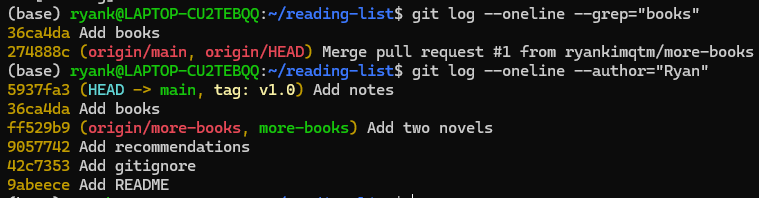

git log --oneline --grep="books"

git log --oneline --author="Ryan"

### Task 11: make Git yours (research)

Create two Git aliases with `git config --global`: `git st` for `status` and `git last` for showing only the most recent commit. Show both aliases working. One sentence: in which file does Git store them?

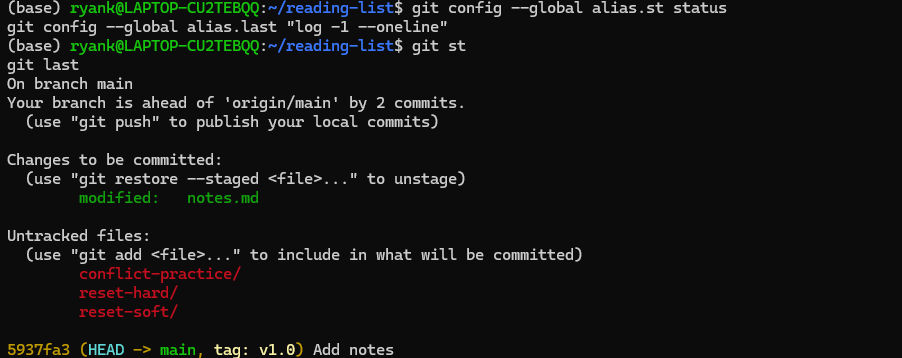

git stores them in global git config file in my home directory

### Task 12: committed by mistake (research)

Run this setup:

```bash
mkdir secret-practice
cd secret-practice
git init
echo "api_key=12345" > secrets.txt
git add secrets.txt
git commit -m "Add config"
```

The key file should never have been committed. Make Git stop tracking `secrets.txt` while keeping the file on disk, commit that change, and make sure the file cannot be accidentally committed again. Verify with `git status` that the file no longer appears. Two sentences: what did you do, and why does deleting the file with `rm` not solve the problem?

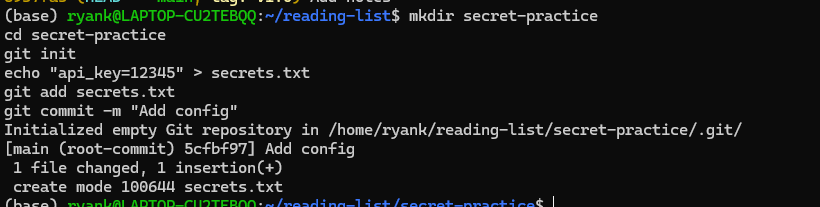
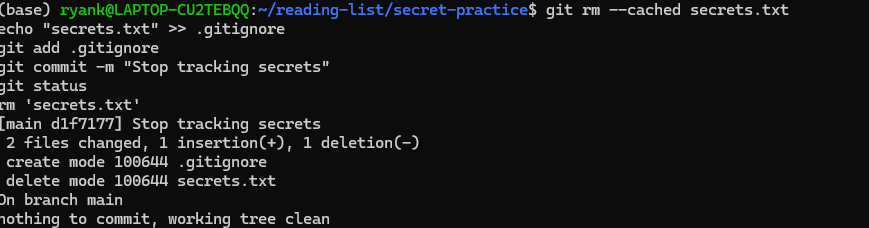

git rm --cached secrets.txt

echo "secrets.txt" >> .gitignore

git add .gitignore

git commit -m "Stop tracking secrets"

git status

I stopped Git from tracking secrets.txt but kept the file on my computer. Using rm would delete the file, but the secret would still exist in the old commit.